In [1]:
from stark_qa import load_skb, load_qa
import sys

OpenAI API key found.


In [2]:
import os
from dotenv import load_dotenv

load_dotenv(override=True)

# print("OPENAI_API_KEY =", os.getenv("OPENAI_API_KEY"))
# print("NVIDIA_API_KEY =", os.getenv("NVIDIA_API_KEY"))


True

In [3]:
print(sys.executable)

/home/payal-s/.pyenv/versions/3.10.18/bin/python


In [4]:
from custom_pipeline.entity_parsing import *
from custom_pipeline.relation_parsing import *
from custom_pipeline.llm_bridge import LlmBridge

In [5]:
data_split = 'test'

emb_model = 'text-embedding-ada-002'
configs_path = 'configs.json'

In [6]:
qa_dataset = load_qa('amazon')
qa = qa_dataset.split_indices[data_split].reshape(-1).tolist()
qa = qa[:int(len(qa) * 0.1)]
test_queries = [qa_dataset[i] for i in qa]


Use file from /home/payal-s/.cache/huggingface/hub/datasets--snap-stanford--stark/snapshots/88269e23e90587f99476c5dd74e235a0877e69be/qa/amazon/stark_qa/stark_qa_human_generated_eval.csv.


In [7]:

dataset_name = 'prime'
kb = load_skb(dataset_name, download_processed=True)


Loading from /home/sarthak/.cache/huggingface/hub/datasets--snap-stanford--stark/snapshots/88269e23e90587f99476c5dd74e235a0877e69be/skb/prime/processed!


In [37]:
# model_name = "openai/gpt-oss-120b"  # or "deepseek-chat", "gemini-pro", etc.
model_name = 'meta/llama-3.3-70b-instruct' 

# Optional: Initialize logger if you want logging
# logger = Logger("temp/")  # Adjust based on your Logger implementation

# Create LLM Bridge instance
llm_bridge = LlmBridge(model_name=model_name,configs_path="configs.json", verbose=False)

# framework = Framework("cypher_notebook", dataset_name, data_split, llm_model=llm_model, enable_vss=True,
#                   emb_model=emb_model, configs_path=configs_path)
# alpha = framework.settings.get("alpha")

# nodes_to_consider = str(kb.node_type_lst()).replace("'","")
# # edges_to_consider = str(list(framework.settings.configs.get("edge_type_long2short").keys())).replace("'","")
# # properties_to_consider = str(list(framework.settings.configs.get("avail_node_properties").keys())).replace("'","")
# relation_names = ['ppi', 'carrier', 'enzyme', 'target', 'transporter', 'contraindication', 'indication', 'off-label use', 'synergistic interaction', 'associated with', 'parent-child', 'phenotype absent', 'phenotype present', 'side effect', 'interacts with', 'linked to', 'expression present', 'expression absent']

In [8]:

from typing import List, Dict, Any
class Query:
    """
    A class to hold the attributes of a query and its processing state.
    """    
    def __init__(
        self, 
        id: Any, 
        query: str, 
        ground_truths: List[Any],
        status: str = "IN_PROGRESS",
        prompt: str = "",
        entities: Dict[str, Any] = None,
        symbol_candidates: Dict[str, Any] = None,
        relations : Dict[tuple, Any] = None ,
    ):
        self.id = id
        self.query = query
        self.ground_truths = ground_truths
        self.status = status
        self.entity_id_response = ""
        self.relations_id_response = ""
        self.relations = relations        
        # Use None as default for mutable types (dicts/lists)
        # and initialize to empty dict if None is passed.
        self.entities = entities if entities is not None else {}
        self.initial_symbol_candidates = symbol_candidates if symbol_candidates is not None else {}
        self.relations = entities if entities is not None else {}
        self.results = {}

    def __repr__(self) -> str:
        """Provides a clean string representation for the object."""
        return (f"Query(id={self.id!r}, query={self.query!r}, "
                f"status={self.status!r}, ground_truths={self.ground_truths!r})")

In [9]:
q = test_queries[16]
print(q)
current_query = Query(id=0,query=q[0] , ground_truths=q[2]) 

print(current_query)

("What are some recommended morale patches from Neo Tactical Gear that come with a reliable satisfaction guarantee, as I'm looking to add to my collection?", 8288, [862835], None)
Query(id=0, query="What are some recommended morale patches from Neo Tactical Gear that come with a reliable satisfaction guarantee, as I'm looking to add to my collection?", status='IN_PROGRESS', ground_truths=[862835])


In [10]:
from custom_pipeline.prompt_generator import get_entity_extraction_prompt, get_relation_extraction_prompt

In [16]:
# Step 1 : getting Entities from LLM

def generate_entity_identification_prompt(query_str) :
    return get_entity_extraction_prompt(query_str, "amazon")
    
def get_llm_response(prompt) :
    response = llm_bridge.ask_llm_batch([prompt])
    return response[0][0]

def step1_identify_entities(query: Query) :
    prompt = generate_entity_identification_prompt(query.query)
    response_string = get_llm_response(prompt)
    query.entity_id_response = response_string
    if response_string == '' :
        query.status = "FAILED"
        return # should i be doing this ??
    else :
        try :
            identified_entities = parse_entity_response(response_string)
            query.entities = identified_entities
        except ValueError as e:
            query.status = "FAILED"
            print(f"Error parsing response for query {e}")

In [17]:
step1_identify_entities(current_query)

[LlmBridge] ask_llm_batch: first query (if exists): ENTITY EXTRACTION TASK

    OBJECTIVE: Extract entities from a natural language query and structure them in JSON format. One entity must be designated as "ANSWER", and others should use placeholder names (A, B, C, etc.).

    EXTRACTION RULES

    Rule 1: Entity Types
    Only extract entities mentioned in the query.For each entity, provide a list of possible types from this list: product, brand, color, category. THE ENTITY TYPE SHOULD NOT BE ANY OTHER THAN THESE. An entity may have multiple types.
    If a general entity is mentioned in the query , extract it as an entity too and IF there is no semantic information for it, use the entire query as a semantic constraint for it, else use the semantic .
    DO NOT EVER assign an entity a possible type not in this list.

    Rule 2: Properties
    If an entity has specific properties mentioned in the query, include them. Properties must be from this list: title, name.

    Rule 3: Lexical

In [18]:
print(current_query.entity_id_response)

{
  "A": {
    "type": ["brand"],
    "lexical": {"name": "Neo Tactical Gear"},
    "semantic": ["Neo Tactical Gear"],
    "constant": true
  },
  "B": {
    "type": ["category"],
    "lexical": {"name": "morale patches"},
    "semantic": ["morale patches"],
    "constant": true
  },
  "ANSWER": {
    "type": ["product"],
    "lexical": {},
    "semantic": ["recommended morale patches", "come with a reliable satisfaction guarantee", "add to my collection"],
    "constant": false
  }
}


In [19]:
### Step 2 : identifying the relations between entities 


def generate_relation_identification_prompt(query_string,entities_string) :
    return get_relation_extraction_prompt("amazon", query_string, entities_string)
    
def step2_identify_relations(query: Query) :
    prompt = generate_relation_identification_prompt(query.query,str(query.entities))
    response_string = get_llm_response(prompt)
    query.relations_id_response = response_string

    if response_string == '' :
        query.status = "FAILED"
        return # should i be doing this ??
    else :
        try :
            identified_relations = parse_relation_string(response_string)
            query.relations = identified_relations
        except ValueError as e:
            query.status = "FAILED"
            print(f"Error parsing response for query {e}")

In [20]:
step2_identify_relations(current_query)

[LlmBridge] ask_llm_batch: first query (if exists): RELATION EXTRACTION TASK
        OBJECTIVE: Given a natural language query Q and a set of identified entities from that query, identify all possible relations (edges) between these entities that are implied by the query.

        TASK REQUIREMENTS

        1. Identify all possible edges between entities that can be understood from the query. Consider all entity pairs.

        2. For each identified relation, provide a list of possible edge types. Since edges are undirected, if you think A-rel1->B and A<-rel2-B, include both relations as (A,B): [rel1, rel2] in your answer.

        3. The ANSWER entity must be associated with at least one of the other identified entities.

        EDGE TYPE IDENTIFICATION PROCESS

        Step 1: Consider Initial Edge Types
        Start by considering all semantically relevant edge types from this list: also_buy, also_view, has_brand, has_category, has_color THE RELATION TYPE SHOULD NOT BE ANY OTHER 

In [22]:
current_query.relations

{('ANSWER', 'A'): ['has_brand'], ('ANSWER', 'B'): ['has_category']}

In [23]:
len(test_queries)

164

In [33]:
from tqdm import tqdm

In [38]:
rows = []

In [39]:
def get_llm_reponses(current_query):
    step1_identify_entities(current_query)
    if current_query.status == "FAILED":
        return 0
    step2_identify_relations(current_query)
    

In [40]:
for q in tqdm(test_queries,desc="Processing Queries", unit=" query") :
    current_query = Query(id=q[1],query=q[0] , ground_truths=q[2]) 
    get_llm_reponses(current_query)

    rows.append([
        current_query.id,
        current_query.query,
        current_query.entities,
        current_query.relations
    ])

Processing Queries:  70%|███████   | 115/164 [05:26<02:11,  2.69s/ query]

Error parsing response for query Failed to parse relation string: invalid syntax. Perhaps you forgot a comma? (<unknown>, line 1)
Original: {"("ANSWER", "A")": ["has_category"]}


Processing Queries:  80%|███████▉  | 131/164 [06:05<01:20,  2.43s/ query]

Error parsing response for query Failed to parse relation string: invalid syntax. Perhaps you forgot a comma? (<unknown>, line 1)
Original: {"("ANSWER", "A")": ["has_brand"]}


Processing Queries: 100%|██████████| 164/164 [07:44<00:00,  2.83s/ query]


In [41]:
import pandas as pd
df = pd.DataFrame(rows, columns=["id", "query", "entities", "relations"])
df.to_csv("name.csv", index=False)

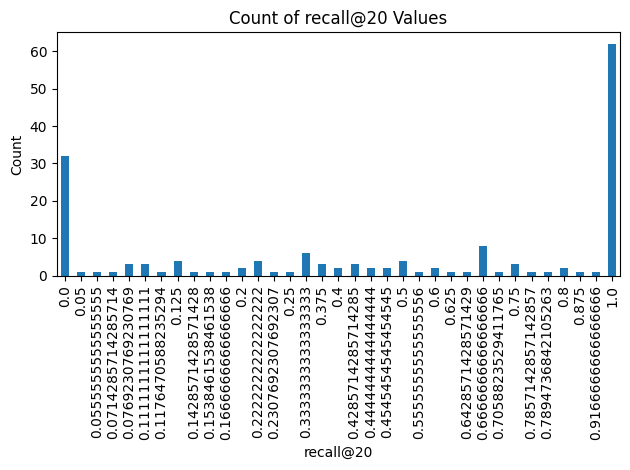

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv("results.csv")

# Ensure 'recall@20' exists
if 'recall@20' in df.columns:
    recall_counts = df['recall@20'].value_counts().sort_index()

    plt.figure()
    recall_counts.plot(kind='bar')
    plt.title('Count of recall@20 Values')
    plt.xlabel('recall@20')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

    df['recall_group'] = df['recall@20'].apply(
        lambda x: '0' if x == 0 else ('1' if x == 1 else 'between')
    )

    group_counts = df['recall_group'].value_counts()

    group_counts.plot(kind='bar')
    plt.title('Distribution of recall@20 Groups')
    plt.xlabel('Recall@20 Category')
    plt.ylabel('Count')
    plt.show()
    else:
    print("Column 'recall@20' not found in the CSV file.")



In [ ]:
## intermediate step : initializing VSS (fucntion definitions and all)


from custom_pipeline.vss_retreiver import VSSRetriever

# Initialize the retriever
retriever = VSSRetriever(
    kb=kb,
    emb_base_path="./emb/prime",
    emb_model="text-embedding-ada-002",
    qa_dataset=qa_dataset,
    dataset_name="test",
    use_vss=True  # Set to True if you need VSS object for generating new embeddings
)

# Now you can use the retriever
print("Available node types:", retriever.get_available_node_types())
# Retrieve top k nodes
top_nodes, scores = retriever.get_top_k_nodes(
    search_str="your query here",
    k=10,
    node_type="drug",
    cutoff=0.5
)

# Access the loaded embeddings if needed
entity_emb_dict = retriever.entity_emb_dict
query_emb_dict = retriever.query_emb_dict
candidate_emb_dict = retriever.candidate_emb_dict
node_emb_dict = retriever.node_emb_dict

Loading query embeddings from emb/prime/text-embedding-ada-002/query/query_emb_dict.pt.
Loaded 11204 query embeddings from emb/prime/text-embedding-ada-002/query/query_emb_dict.pt!
Loaded embeddings of nodes from emb/prime/text-embedding-ada-002/nodes!
Loaded 684 entity embeddings from emb/prime/text-embedding-ada-002/entities/entity_emb_dict.pt!
Available node types: ['biological_process', 'exposure', 'gene/protein', 'drug', 'pathway', 'effect/phenotype', 'anatomy', 'molecular_function', 'cellular_component', 'disease']
Getting embedding for query: your query here using model: text-embedding-ada-002


In [ ]:
print(current_query.entities)

{'A': {'type': ['gene/protein'], 'lexical': {'name': 'SLC29A3'}, 'semantic': [], 'constant': True}, 'B': {'type': ['drug'], 'lexical': {'name': 'Goserelin'}, 'semantic': [], 'constant': True}, 'ANSWER': {'type': ['disease'], 'lexical': {}, 'semantic': ['linked to the gene SLC29A3', 'should not be treated with the drug Goserelin'], 'constant': False}}


In [ ]:
## Step 3 : getting initial candidates for all the symbols except answer 
from custom_pipeline.candidate_context import CandidateContext

In [ ]:
def get_initial_candidates_for_entity(entity_info, entity_key, kb, retriever):
    print(entity_info)
    # entity_info = entity_info[entity_key]
    candidates = []
    entity_types = entity_info.get("type", [])
    name_constraint = entity_info.get("lexical", {}).get("name", None)
    semantic_constraints = entity_info.get("semantic", []).copy()
    # if len(semantic_constraints) == 0:   ## doing this because there was one node that had some phrase "a b c" , "a b" was identified as name, only c didn't make sense as lexical constraint
    #     semantic_constraints = []
    for key in entity_info.get("lexical", {}):
        semantic_constraints.append(f" {entity_info['lexical'][key]}")
   
    nodes_by_name = []

    if name_constraint:
        for etype in entity_types:
            print("Searching for entity type:", etype)
            nodes_by_name = kb.get_node_ids_by_value(node_type=etype, key="name", value=name_constraint)
            print("Found nodes by name:", nodes_by_name)
            candidates.extend([CandidateContext(node_id=x, entity=entity_key,score=1)for x in nodes_by_name])

    vss_candidates_count = 25 - len(candidates) # total 25 candidates instead of 20 

    for etype in entity_types : 
        sem = "".join(semantic_constraints)
        print("Searching for semantic constraint:", sem)
        nodes_by_desc_ids , vss_scores = retriever.get_top_k_nodes(search_str=sem, k=vss_candidates_count, node_type=etype, cutoff=0.65) # adding a cutoff
        candidates.extend([CandidateContext(node_id=nodes_by_desc_ids[x], entity=entity_key,score=vss_scores[x])for x in range(len(nodes_by_desc_ids)) if nodes_by_desc_ids[x] not in nodes_by_name])
        print("Found nodes by description:", len(nodes_by_desc_ids))
            # candidates.extend(nodes_by_desc)
    print("Candidates so far:", candidates)
    return candidates # Remove duplicates


In [ ]:
def step3_get_initial_candidates(current_query) : 
    initial_candidates = {}
    print(initial_candidates)
    for entity in current_query.entities:
        print("Entity:", entity)
        if entity == "ANSWER":
            continue
        initial_candidates[entity] = get_initial_candidates_for_entity(current_query.entities[entity],entity_key=entity,kb=kb,retriever=retriever)
    current_query.initial_symbol_candidates = initial_candidates

In [ ]:
step3_get_initial_candidates(current_query)

{}
Entity: A
{'type': ['gene/protein'], 'lexical': {'name': 'SLC29A3'}, 'semantic': [], 'constant': True}
Searching for entity type: gene/protein
Found nodes by name: [21961]
Searching for semantic constraint:  SLC29A3
Getting embedding for query:  SLC29A3 using model: text-embedding-ada-002
Found nodes by description: 24
Candidates so far: [CandidateContext(
  node_id=21961,
  entity=A,
  score=1,
  support=0,
  triplets=[],
  symbol_candidates={}
), CandidateContext(
  node_id=81754,
  entity=A,
  score=0.8056660294532776,
  support=0,
  triplets=[],
  symbol_candidates={}
), CandidateContext(
  node_id=34255,
  entity=A,
  score=0.8012831807136536,
  support=0,
  triplets=[],
  symbol_candidates={}
), CandidateContext(
  node_id=59375,
  entity=A,
  score=0.8005552291870117,
  support=0,
  triplets=[],
  symbol_candidates={}
), CandidateContext(
  node_id=59391,
  entity=A,
  score=0.7996883988380432,
  support=0,
  triplets=[],
  symbol_candidates={}
), CandidateContext(
  node_id=

In [ ]:
current_query.initial_symbol_candidates

{'A': [CandidateContext(
    node_id=21961,
    entity=A,
    score=1,
    support=0,
    triplets=[],
    symbol_candidates={}
  ),
  CandidateContext(
    node_id=81754,
    entity=A,
    score=0.8056660294532776,
    support=0,
    triplets=[],
    symbol_candidates={}
  ),
  CandidateContext(
    node_id=34255,
    entity=A,
    score=0.8012831807136536,
    support=0,
    triplets=[],
    symbol_candidates={}
  ),
  CandidateContext(
    node_id=59375,
    entity=A,
    score=0.8005552291870117,
    support=0,
    triplets=[],
    symbol_candidates={}
  ),
  CandidateContext(
    node_id=59391,
    entity=A,
    score=0.7996883988380432,
    support=0,
    triplets=[],
    symbol_candidates={}
  ),
  CandidateContext(
    node_id=11441,
    entity=A,
    score=0.7992763519287109,
    support=0,
    triplets=[],
    symbol_candidates={}
  ),
  CandidateContext(
    node_id=127437,
    entity=A,
    score=0.7989563941955566,
    support=0,
    triplets=[],
    symbol_candidates={}
 

In [ ]:
# Step 4 : Grounding

from custom_pipeline.priority_queue_grounding import PriorityQueueGrounding
# print(dir(PriorityQueueGrounding))  # Should show 'ground' in the list


In [ ]:
print("HELOOOO")

HELOOOO


In [ ]:
import heapq
from typing import Dict, Set, List, Tuple
from collections import defaultdict
from custom_pipeline.candidate_context import CandidateContext
from custom_pipeline.priority_queue_grounding import PriorityQueueGrounding


def run_priority_queue_grounding(
    query_obj,
    kb,
    vss_retriever,
    max_candidates_per_symbol: int = 1000,
    max_answer_candidates: int = 50,
    top_k_neighbors: int = 10,
    score_decay: float = 0.9,
    support_boost : float = 0.15 ,
    verbose: bool = False
) -> Dict[str, List[CandidateContext]]:
    """
    Convenience function to run priority queue-based grounding.
    
    Args:
        query_obj: Query class instance with entities, relations, and initial_symbol_candidates
        kb: Knowledge base object
        vss_retriever: VSSRetriever instance for scoring neighbors
        max_candidates_per_symbol: Max candidates per entity (default 1000)
        max_answer_candidates: Max candidates for ANSWER entity (default 100)
        top_k_neighbors: Number of top neighbors to add per expansion (default 10)
        score_decay: Score decay factor for propagation (default 0.9)
        verbose: Print detailed logs (default True)
    
    Returns:
        Dictionary mapping entity symbols to lists of CandidateContext objects
    """
    grounder = PriorityQueueGrounding(
        query_obj=query_obj,
        kb=kb,
        vss_retriever=vss_retriever,
        max_candidates_per_symbol=max_candidates_per_symbol,
        max_answer_candidates=max_answer_candidates,
        top_k_neighbors=top_k_neighbors,
        score_decay=score_decay,
        support_boost=support_boost,
        verbose=verbose
    )
    
    return grounder.ground()

In [ ]:
def evaluate_result(predicted_nodes,ground_truth_nodes) : 
    
    # Convert ground truth to set for O(1) lookup
    ground_truth_set = set(ground_truth_nodes)
    
    # Handle empty predictions - THIS MUST BE FIRST
    if not predicted_nodes:
        return {
            "answer_set": set(),
            "ground_truth_set": ground_truth_set,
            "retrieved_ground_truths": set(),
            "missed_ground_truths": ground_truth_set,
            "metrics": {
                "total_answers": len(ground_truth_set),
                "retrieved_count": 0,
                "missed_count": len(ground_truth_set),
                "recall@50": 0.0,
                "hit_at_1": 0.0,
                "hit_at_5": 0.0,
                "mrr": 0.0,
            }
        }
    
    # Hit@1: Check if the first predicted node is in ground truth
    hit_at_1 = 1.0 if predicted_nodes[0] in ground_truth_set else 0.0
    
    # Hit@5: Check if any of the first 5 predicted nodes are in ground truth
    hit_at_5 = 1.0 if any(node in ground_truth_set for node in predicted_nodes[:5]) else 0.0
    
    # MRR (Mean Reciprocal Rank): Find the rank of the first relevant item
    mrr = 0.0
    for rank, node in enumerate(predicted_nodes, 1):
        if node in ground_truth_set:
            mrr = 1.0 / rank
            break
    answer_set = set(predicted_nodes)
    retieved_ground_truths = answer_set.intersection(ground_truth_set)
    missed_ground_truths = ground_truth_set.difference(retieved_ground_truths)
    retieved_ground_truths_count = len(retieved_ground_truths)
    missed_ground_truths_count = len(missed_ground_truths)
    recall = retieved_ground_truths_count / len(ground_truth_set) if len(ground_truth_set) > 0 else 0.0
        # Recall@20
    top_20_predictions = predicted_nodes[:20]
    retrieved_20 = set(top_20_predictions).intersection(ground_truth_set)
    recall_20 = len(retrieved_20) / len(ground_truth_set) if len(ground_truth_set) > 0 else 0.0

    # Store all results in a dictionary
    results = {
        # "answer_set": answer_set,
        "answer_list": predicted_nodes,
        "ground_truth_set": ground_truth_set,
        "retrieved_ground_truths": retieved_ground_truths,
        "missed_ground_truths": missed_ground_truths,
        "metrics": {
        "total_answers" : len(ground_truth_set),
        "retrieved_count": retieved_ground_truths_count,
        "missed_count": missed_ground_truths_count,
        "recall@50": recall,        
        "recall@20" : recall_20 , 
        'hit_at_1': hit_at_1,
        'hit_at_5': hit_at_5,
        'mrr': mrr,
        }


    }
    return results

In [ ]:
def step4_grounding(query : Query ) :
    final_candidates = run_priority_queue_grounding(
        query_obj=query,  # Your Query instance
        kb=kb,
        vss_retriever=retriever,
        max_candidates_per_symbol=3000, # increasing max canidates per symbol to 3000
        max_answer_candidates=100,
        top_k_neighbors=20,
        support_boost=0.35,   # increasing support boost 
        score_decay=0.9,
        verbose=True
    )
    answers = [cc.node_id for cc in  sorted(final_candidates["ANSWER"], key = lambda x : (x.score , - x.support), reverse= True)  ]
    # reranking candidates using support, followed by score.
    results = evaluate_result(answers,query.ground_truths)
    query.results = results
    return final_candidates




In [ ]:
current_query.query

'Find medical conditions linked to the gene SLC29A3 that should not be treated with the drug Goserelin.'

In [ ]:
# current_query.results["answer_set"]

In [ ]:
final_candidates = step4_grounding(current_query)


[INIT] Initializing priority queues with initial candidates
Getting embedding for query: SLC29A3 using model: text-embedding-ada-002
  Entity 'A' query: 'SLC29A3'
Getting embedding for query: Goserelin using model: text-embedding-ada-002
  Entity 'B' query: 'Goserelin'
Getting embedding for query: linked to the gene SLC29A3 should not be treated with the drug Goserelin using model: text-embedding-ada-002
  Entity 'ANSWER' query: 'linked to the gene SLC29A3 should not be treated with the drug Goserelin'
  Initialized 'A' with 24 candidates
  Initialized 'B' with 24 candidates
  Initialized 'ANSWER' with 0 candidates

[INFO] Relations to process: {('A', 'ANSWER'): ['associated with'], ('B', 'ANSWER'): ['contraindication']}

[INFO] Entity relations lookup:
  A: [('ANSWER', ['associated with'])]
  ANSWER: [('A', ['associated with']), ('B', ['contraindication'])]
  B: [('ANSWER', ['contraindication'])]

[INFO] Starting round-robin grounding
[INFO] Processing order (per round): ['A', 'B']



In [ ]:
print(final_candidates)

defaultdict(<class 'list'>, {'A': [CandidateContext(
  node_id=21961,
  entity=A,
  score=1,
  support=0,
  triplets=[],
  symbol_candidates={}
), CandidateContext(
  node_id=81754,
  entity=A,
  score=0.8056660294532776,
  support=0,
  triplets=[],
  symbol_candidates={}
), CandidateContext(
  node_id=34255,
  entity=A,
  score=0.8012831807136536,
  support=0,
  triplets=[],
  symbol_candidates={}
), CandidateContext(
  node_id=59375,
  entity=A,
  score=0.8005552291870117,
  support=0,
  triplets=[],
  symbol_candidates={}
), CandidateContext(
  node_id=59391,
  entity=A,
  score=0.7996883988380432,
  support=0,
  triplets=[],
  symbol_candidates={}
), CandidateContext(
  node_id=11441,
  entity=A,
  score=0.7992763519287109,
  support=0,
  triplets=[],
  symbol_candidates={}
), CandidateContext(
  node_id=127437,
  entity=A,
  score=0.7989563941955566,
  support=0,
  triplets=[],
  symbol_candidates={}
), CandidateContext(
  node_id=83010,
  entity=A,
  score=0.7987083792686462,
  s

In [ ]:
print(current_query.relations_id_response)
print(current_query.results)

{
  ("A", "ANSWER"): ["associated with"],
  ("B", "ANSWER"): ["contraindication"]
}
{'answer_list': [29113, 27219, 27933, 28407, 37044, 36043, 35583, 30438, 36453, 38682, 37703, 33656, 83840, 36923, 28552, 36035, 33575, 33528, 31109, 33616, 38898, 83760, 33577, 28651, 83764, 33636, 30877, 33593, 36544, 32617, 35771, 84243, 28347, 36538, 28849, 36480, 30035, 36691, 35704, 28313, 84244, 39859, 37858, 36512, 29089, 32740, 29652, 27472, 29050, 35641, 37448, 39815, 35961, 27326, 35817, 33341, 30382, 83906, 31245, 27655, 36743, 36893, 35565, 83928, 83836, 83875, 83922, 36398, 39531, 36785, 36849, 35958, 39491, 33598, 35660, 33679, 83823, 83824, 38040, 37180, 29525, 83751, 83837, 31650, 84283, 35909, 33594], 'ground_truth_set': {29113}, 'retrieved_ground_truths': {29113}, 'missed_ground_truths': set(), 'metrics': {'total_answers': 1, 'retrieved_count': 1, 'missed_count': 0, 'recall@50': 1.0, 'recall@20': 1.0, 'hit_at_1': 1.0, 'hit_at_5': 1.0, 'mrr': 1.0}}


In [ ]:
## saving results 
import csv
from pathlib import Path
from typing import Optional

def save_results(
    query: Query, 
    csv_path: str = "pipeline_results.csv",
    append: bool = True
):
    """
    Save query results metrics to a CSV file.
    
    Args:
        query: Query object with results populated
        csv_path: Path to the CSV file (default: "pipeline_results.csv")
        append: If True, append to existing file; if False, overwrite (default: True)
    """
    csv_file = Path(csv_path)
    
    # Check if file exists and if we should write headers
    file_exists = csv_file.exists()
    write_headers = not file_exists or not append
    
    # Open file in append or write mode
    mode = 'a' if append else 'w'
    
    # Extract metrics from query results
    if not hasattr(query, 'results') or query.results is None:
        print(f"[WARNING] Query {query.id} has no results. Skipping.")
        return
    
    metrics = query.results.get('metrics', {})
    
    # Prepare row data
    row_data = {
        'query_id': query.id,
        'query_text': query.query,
        'total_answers': metrics.get('total_answers', 0),
        'retrieved_count': metrics.get('retrieved_count', 0),
        'missed_count': metrics.get('missed_count', 0),
        'recall@20': metrics.get('recall@20', 0.0),
        'recall@50': metrics.get('recall@50', 0.0),
        'hit@1': metrics.get('hit_at_1', 0.0),
        'hit@5': metrics.get('hit_at_5', 0.0),
        'mrr': metrics.get('mrr', 0.0),
    }
    
    # Define fieldnames (column order)
    fieldnames = [
        'query_id',
        'query_text',
        'total_answers',
        'retrieved_count',
        'missed_count',
        'recall@50',
        'recall@20',
        'hit@1',
        'hit@5',
        'mrr'
    ]
    
    with open(csv_file, mode, newline='', encoding='utf-8') as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        
        # Write header if needed
        if write_headers:
            writer.writeheader()
        
        # Write the data row
        writer.writerow(row_data)
    
    print(f"[SAVED] Results for query {query.id} saved to {csv_path}")


def save_aggregate_results(
    queries: list,
    csv_path: str = "aggregate_results.csv"
):
    """
    Calculate and save aggregate metrics across all queries.
    
    Args:
        queries: List of Query objects with results
        csv_path: Path to save aggregate results
    """
    if not queries:
        print("[WARNING] No queries provided for aggregation.")
        return
    
    # Collect all metrics
    all_metrics = []
    for query in queries:
        if hasattr(query, 'results') and query.results is not None:
            all_metrics.append(query.results.get('metrics', {}))
    
    if not all_metrics:
        print("[WARNING] No valid results found in queries.")
        return
    
    # Calculate averages
    num_queries = len(all_metrics)
    avg_metrics = {
        'total_queries': num_queries,
        'avg_total_answers': sum(m.get('total_answers', 0) for m in all_metrics) / num_queries,
        'avg_retrieved_count': sum(m.get('retrieved_count', 0) for m in all_metrics) / num_queries,
        'avg_missed_count': sum(m.get('missed_count', 0) for m in all_metrics) / num_queries,
        'avg_recall@20': sum(m.get('recall@20', 0.0) for m in all_metrics) / num_queries,
        'avg_recall@50': sum(m.get('recall@50', 0.0) for m in all_metrics) / num_queries,
        'avg_hit@1': sum(m.get('hit_at_1', 0.0) for m in all_metrics) / num_queries,
        'avg_hit@5': sum(m.get('hit_at_5', 0.0) for m in all_metrics) / num_queries,
        'avg_mrr': sum(m.get('mrr', 0.0) for m in all_metrics) / num_queries,
    }
    
    # Write to CSV
    fieldnames = list(avg_metrics.keys())
    
    with open(csv_path, 'w', newline='', encoding='utf-8') as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerow(avg_metrics)
    
    print(f"[SAVED] Aggregate results saved to {csv_path}")
    print(f"\nAggregate Metrics:")
    for key, value in avg_metrics.items():
        print(f"  {key}: {value:.4f}" if isinstance(value, float) else f"  {key}: {value}")



In [ ]:

qa_dataset = load_qa('prime')
qa = qa_dataset.split_indices[data_split].reshape(-1).tolist()
qa = qa[:int(len(qa) * 0.1)]
# qa = [7152, 5659, 3478, 9020, 9257, 6522, 181, 4045, 1118]
test_queries = [qa_dataset[i] for i in qa]

Use file from /home/sarthak/.cache/huggingface/hub/datasets--snap-stanford--stark/snapshots/88269e23e90587f99476c5dd74e235a0877e69be/qa/prime/stark_qa/stark_qa_human_generated_eval.csv.


In [ ]:
import os

# Specify the directory name
exp_name = "TEMP3"

# Create the directory
try:
    os.mkdir(f"./output/{exp_name}")
    print(f"Directory '{exp_name}' created successfully.")
except FileExistsError:
    print(f"Directory '{exp_name}' already exists.")
except PermissionError:
    print(f"Permission denied: Unable to create '{exp_name}'.")
except Exception as e:
    print(f"An error occurred: {e}")
# print([query[1] for query in test_queries])



Directory 'TEMP3' already exists.


In [ ]:
import pandas as pd
df = pd.read_csv('./STEP2_results/full_data_dump.csv',header=0)

queries = []

import json
import ast
import math
import re

def parse_mixed(val):
    # Already parsed dict
    if isinstance(val, dict):
        return val

    # NaN or None
    if val is None or (isinstance(val, float) and math.isnan(val)):
        return {}

    s = str(val).strip()

    # Remove one outer layer of quotes
    if (s.startswith('"') and s.endswith('"')) or (s.startswith("'") and s.endswith("'")):
        s = s[1:-1].strip()

    # ---- Try JSON first ----
    try:
        return json.loads(s)
    except:
        pass

    # ---- Convert JSON tokens -> Python tokens ----
    # true -> True, false -> False, null -> None
    fixed = (
        s.replace("true", "True")
         .replace("false", "False")
         .replace("null", "None")
    )

    # ---- Try Python literal ----
    try:
        return ast.literal_eval(fixed)
    except:
        print("UNPARSABLE STRING:", repr(s))
        raise

stored_data = {}
for index, query in df.iterrows():
    # print(query)
    stored_data[query['id']] = {
        'entities' : (query['entity_id_response']),
        'relations' : (query['relations_id_response'])
    }

print(df.head())

      id                                              query  \
0   6517  Which cell structures are involved in interact...   
1   9996  Which genes or proteins are expressed exclusiv...   
2   3630  Could you suggest any medications effective fo...   
3  10252  Which gene or protein responsible for coding t...   
4   5142  Which autosomal dominant diseases are linked t...   

                  ground_truths       status  \
0  [56241, 55842, 56174, 56263]  IN_PROGRESS   
1                       [10833]  IN_PROGRESS   
2                       [15179]  IN_PROGRESS   
3                    [43, 2140]  IN_PROGRESS   
4                       [30638]  IN_PROGRESS   

                                  entity_id_response  \
0  {\n  "A": {\n    "type": ["drug"],\n    "lexic...   
1  {\n  "A": {\n    "type": ["anatomy"],\n    "le...   
2  {\n  "A": {\n    "type": ["disease"],\n    "le...   
3  {\n  "A": {\n    "type": ["gene/protein", "mol...   
4  {\n  "A": {\n    "type": ["anatomy"],\n    "le...

In [ ]:
stored_data

{6517: {'entities': '{\n  "A": {\n    "type": ["drug"],\n    "lexical": {"name": "Travoprost"},\n    "semantic": [],\n    "constant": true\n  },\n  "B": {\n    "type": ["gene/protein"],\n    "lexical": {},\n    "semantic": ["influenced by the medication Travoprost"],\n    "constant": false\n  },\n  "ANSWER": {\n    "type": ["cellular_component"],\n    "lexical": {},\n    "semantic": ["involved in interaction with genes or proteins"],\n    "constant": false\n  }\n}',
  'relations': '{\n  ("A", "B"): ["target", "carrier", "transporter", "enzyme"],\n  ("B", "ANSWER"): ["interacts with"]\n}'},
 9996: {'entities': '{\n  "A": {\n    "type": ["anatomy"],\n    "lexical": {"name": "pericardium"},\n    "semantic": [],\n    "constant": true\n  },\n  "B": {\n    "type": ["anatomy"],\n    "lexical": {"name": "thalamus"},\n    "semantic": ["dorsal region", "ventral region"],\n    "constant": true\n  },\n  "ANSWER": {\n    "type": ["gene/protein"],\n    "lexical": {},\n    "semantic": [\n      "expre

In [ ]:
def dummy_step1_identify_entities(current_query):
    response_string = ""
    if current_query.id in stored_data :
        response_string = stored_data[current_query.id]['entities']
        current_query.entity_id_response = response_string

    else :
        response_string = ''
    
    if response_string == '':
        current_query.status = "FAILED"
        return  # should i be doing this ??
    else:
        try:
            identified_entities = parse_entity_response(response_string)
            current_query.entities = identified_entities
        except ValueError as e:
            current_query.status = "FAILED"
            print(f"Error parsing response for query {e}")

# def step1_identify_entities(query: Query) :
    
#     query.entity_id_response = response_string
#     if response_string == '' :
#         query.status = "FAILED"
#         return # should i be doing this ??
#     else :
#         try :
#             identified_entities = parse_entity_response(response_string)
#             query.entities = identified_entities
#         except ValueError as e:
#             query.status = "FAILED"
#             print(f"Error parsing response for query {e}")

def dummy_step2_identify_relations(current_query) : 
    response_string = ""
    if current_query.id in stored_data :
        response_string = stored_data[current_query.id]['relations']
    else :
        response_string = ''
    current_query.relations_id_response = response_string
    if response_string == '' :
        current_query.status = "FAILED"
        return # should i be doing this ??
    else :
        try :
            identified_relations = parse_relation_string(response_string)
            current_query.relations = identified_relations
        except ValueError as e:
            current_query.status = "FAILED"
            print(f"Error parsing response for query {e}")

# def step2_identify_relations(query: Query) :
    # prompt = generate_relation_identification_prompt(query.query,str(query.entities))
    # response_string = get_llm_response(prompt)
    # query.relations_id_response = response_string

    # if response_string == '' :
    #     query.status = "FAILED"
    #     return # should i be doing this ??
    # else :
    #     try :
    #         identified_relations = parse_relation_string(response_string)
    #         query.relations = identified_relations
    #     except ValueError as e:
    #         query.status = "FAILED"
    #         print(f"Error parsing response for query {e}")

In [ ]:
def pipeline(query):
    dummy_step1_identify_entities(query)
    dummy_step2_identify_relations(query)
    print(query)
    step3_get_initial_candidates(query)
    step4_grounding(query)
    save_results(query, csv_path=f"./output/{exp_name}/pipeline_results.csv")


In [ ]:
print(len(test_queries))

280


In [ ]:


results = []
# test_queries = [qa_dataset[i] for i in range(300)] # qa_dataset is something  weird, doesn't allow slicing ig
print(len(test_queries))
# for i in range(20) :
#     print(test_queries[i][1])  

# test_queries = [test_queries[9]]

280


In [ ]:
# print(test_queries)


In [ ]:
import contextlib
import io
import traceback
from tqdm import tqdm

failed_queries = []  # Track failed queries
results = []

for query in tqdm(test_queries, desc="Processing queries", unit="query"):
    try:
        with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
            current_query = Query(id=query[1], query=query[0], ground_truths=query[2]) 
            pipeline(current_query)
        results.append(current_query)
        
    except Exception as e:
        # Get full traceback
        tb = traceback.format_exc()
        
        # Log the error and skip this query
        failed_queries.append({
            'query_id': query[1],
            'query_text': query[0][:100],  # Truncate long queries
            'error': str(e),
            'error_type': type(e).__name__,
            'traceback': tb
        })
        tqdm.write(f"✗ Query {query[1]} failed: {type(e).__name__}: {str(e)}")
        continue

# Save results
save_aggregate_results(results, csv_path=f"./output/{exp_name}/aggregate_results.csv")

# Save failed queries to a separate CSV
if failed_queries:
    import csv
    with open(f"./output/{exp_name}/failed_queries.csv", 'w', newline='', encoding='utf-8') as f:
        writer = csv.DictWriter(f, fieldnames=['query_id', 'query_text', 'error_type', 'error', 'traceback'])
        writer.writeheader()
        writer.writerows(failed_queries)
    print(f"\n⚠ {len(failed_queries)} queries failed. See ./output/failed_queries.csv for details.")
    
    # Print summary of error types
    from collections import Counter
    error_counts = Counter(fq['error_type'] for fq in failed_queries)
    print(f"\nError breakdown:")
    for error_type, count in error_counts.items():
        print(f"  {error_type}: {count}")
else:
    print(f"\n✓ All {len(results)} queries processed successfully!")

print(f"\n📊 Successfully processed: {len(results)} queries")

Processing queries: 100%|██████████| 280/280 [2:15:04<00:00, 28.94s/query]   

[SAVED] Aggregate results saved to ./output/TEMP3/aggregate_results.csv

Aggregate Metrics:
  total_queries: 280
  avg_total_answers: 2.5000
  avg_retrieved_count: 1.5714
  avg_missed_count: 0.9286
  avg_recall@20: 0.5385
  avg_recall@50: 0.6964
  avg_hit@1: 0.2929
  avg_hit@5: 0.4679
  avg_mrr: 0.3681

✓ All 280 queries processed successfully!

📊 Successfully processed: 280 queries


In [ ]:
# 'mean_recall@20': 0.5004326283738049

import csv
import json

def save_aggregate_results(results, csv_path="aggregate_results.csv"):
    """
    Save Query objects to a CSV file, handling dictionary attributes and missing values.
    
    Args:
        results: List of Query objects
        csv_path: Path to save the CSV file
    """
    if not results:
        print("No results to save.")
        return
    
    def serialize_value(value):
        """
        Recursively serialize any value to a JSON-compatible format.
        Handles custom objects by converting them to strings.
        """
        if value is None:
            return ""
        elif isinstance(value, (str, int, float, bool)):
            return value
        elif isinstance(value, dict):
            return {k: serialize_value(v) for k, v in value.items()}
        elif isinstance(value, (list, tuple)):
            return [serialize_value(item) for item in value]
        else:
            # For custom objects, use their string representation
            return str(value)
    
    # Define all possible fieldnames based on Query class attributes
    fieldnames = [
        'id',
        'query',
        'ground_truths',
        'status',
        'entity_id_response',
        'relations_id_response',
        'entities',
        'initial_symbol_candidates',
        'relations',
        'results'
    ]
    
    with open(csv_path, 'w', newline='', encoding='utf-8') as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        
        for query_obj in results:
            row = {}
            
            for field in fieldnames:
                # Get the attribute value, default to empty string if missing
                value = getattr(query_obj, field, "")
                
                # Handle None values
                if value is None:
                    row[field] = ""
                # Handle dictionary attributes - convert to JSON string with serialization
                elif isinstance(value, dict):
                    try:
                        serialized = serialize_value(value)
                        row[field] = json.dumps(serialized) if serialized else ""
                    except Exception as e:
                        # Fallback to string representation if serialization fails
                        row[field] = str(value)
                # Handle list/tuple attributes - convert to JSON string with serialization
                elif isinstance(value, (list, tuple)):
                    try:
                        serialized = serialize_value(value)
                        row[field] = json.dumps(serialized) if serialized else ""
                    except Exception as e:
                        # Fallback to string representation if serialization fails
                        row[field] = str(value)
                # Handle all other types as strings
                else:
                    row[field] = str(value)
            
            writer.writerow(row)
    
    print(f"✓ Successfully saved {len(results)} results to {csv_path}")

# Call the function with your results
save_aggregate_results(results, csv_path=f"./output/{exp_name}/full_data_dump.csv")

✓ Successfully saved 280 results to ./output/TEMP3/full_data_dump.csv


In [ ]:
print("DONE !!!!!!!!!!!!!!")


DONE !!!!!!!!!!!!!!


In [ ]:
import pandas as pd
import contextlib
import io
from tqdm import tqdm
import csv
from typing import List, Dict

def rerun_failed_queries(
    results_csv_path: str = "./output/pipeline_results.csv",
    failed_csv_path: str = "./output/failed_queries.csv",
    test_queries: List = None,
    rerun_zero_recall: bool = True,
    verbose: bool = False
):
    """
    Rerun queries that failed or have zero recall@50, then merge with existing results.
    
    Args:
        results_csv_path: Path to existing pipeline results CSV
        failed_csv_path: Path to failed queries CSV (optional)
        test_queries: List of all test queries [(query_text, query_id, ground_truths), ...]
        rerun_zero_recall: Whether to rerun queries with recall@50 = 0 (default: True)
        verbose: Show detailed grounding logs (default: False)
    
    Returns:
        DataFrame with updated results
    """
    
    # Read existing results
    try:
        existing_results_df = pd.read_csv(results_csv_path)
        print(f"📂 Loaded {len(existing_results_df)} existing results from {results_csv_path}")
    except FileNotFoundError:
        existing_results_df = pd.DataFrame()
        print(f"⚠️  No existing results found at {results_csv_path}")
    
    # Read failed queries
    failed_query_ids = set()
    try:
        failed_df = pd.read_csv(failed_csv_path)
        failed_query_ids = set(failed_df['query_id'].tolist())
        print(f"❌ Found {len(failed_query_ids)} failed queries")
    except FileNotFoundError:
        print(f"ℹ️  No failed queries file found at {failed_csv_path}")
    
    # Identify queries to rerun
    queries_to_rerun = set()
    
    # Add failed queries
    queries_to_rerun.update(failed_query_ids)
    
    # Add zero-recall queries
    if rerun_zero_recall and not existing_results_df.empty:
        zero_recall_ids = existing_results_df[
            existing_results_df['recall@50'] == 0.0
        ]['query_id'].tolist()
        queries_to_rerun.update(zero_recall_ids)
        print(f"🔄 Found {len(zero_recall_ids)} queries with zero recall")
    
    print(f"\n🔄 Total queries to rerun: {len(queries_to_rerun)}")
    
    if not queries_to_rerun:
        print("✅ No queries need to be rerun!")
        return existing_results_df
    
    # Build query lookup dictionary
    if test_queries is None:
        print("❌ Error: test_queries must be provided to rerun queries")
        return existing_results_df
    
    query_lookup = {q[1]: q for q in test_queries}  # {query_id: (query_text, query_id, ground_truths)}
    
    # Rerun queries
    rerun_results = []
    rerun_failed = []
    
    print(f"\n🚀 Starting rerun of {len(queries_to_rerun)} queries...")
    
    for query_id in tqdm(queries_to_rerun, desc="Rerunning queries", unit="query"):
        if query_id not in query_lookup:
            print(f"⚠️  Query ID {query_id} not found in test_queries")
            continue
        
        query_data = query_lookup[query_id]
        
        try:
            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                current_query = Query(
                    id=query_data[1],
                    query=query_data[0],
                    ground_truths=query_data[2]
                )
                pipeline(current_query)
            
            # Extract metrics
            if hasattr(current_query, 'results') and current_query.results:
                metrics = current_query.results.get('metrics', {})
                rerun_results.append({
                    'query_id': current_query.id,
                    'query_text': current_query.query,
                    'total_answers': metrics.get('total_answers', 0),
                    'retrieved_count': metrics.get('retrieved_count', 0),
                    'missed_count': metrics.get('missed_count', 0),
                    'recall@50': metrics.get('recall@50', 0.0),
                    'hit@1': metrics.get('hit_at_1', 0.0),
                    'hit@5': metrics.get('hit_at_5', 0.0),
                    'mrr': metrics.get('mrr', 0.0),
                })
            else:
                raise ValueError("No results generated")
                
        except Exception as e:
            rerun_failed.append({
                'query_id': query_id,
                'query_text': query_data[0][:100],
                'error': str(e),
                'error_type': type(e).__name__
            })
            tqdm.write(f"✗ Query {query_id} failed again: {type(e).__name__}")
    
    print(f"\n✅ Successfully reran: {len(rerun_results)} queries")
    print(f"❌ Failed again: {len(rerun_failed)} queries")
    
    # Create DataFrame from rerun results
    rerun_df = pd.DataFrame(rerun_results)
    
    # Merge with existing results
    if not existing_results_df.empty:
        # Remove old entries for rerun queries
        existing_results_df = existing_results_df[
            ~existing_results_df['query_id'].isin(queries_to_rerun)
        ]
        
        # Concatenate with new results
        merged_df = pd.concat([existing_results_df, rerun_df], ignore_index=True)
    else:
        merged_df = rerun_df
    
    # Sort by query_id
    merged_df = merged_df.sort_values('query_id').reset_index(drop=True)
    
    # Save merged results
    merged_df.to_csv(results_csv_path, index=False)
    print(f"\n💾 Saved {len(merged_df)} results to {results_csv_path}")
    
    # Save updated failed queries
    if rerun_failed:
        failed_df_updated = pd.DataFrame(rerun_failed)
        failed_df_updated.to_csv(failed_csv_path, index=False)
        print(f"💾 Saved {len(rerun_failed)} still-failed queries to {failed_csv_path}")
    
    # Calculate and save aggregate metrics
    aggregate_metrics = {
        'total_queries': len(merged_df),
        'avg_total_answers': merged_df['total_answers'].mean(),
        'avg_retrieved_count': merged_df['retrieved_count'].mean(),
        'avg_missed_count': merged_df['missed_count'].mean(),
        'avg_recall@50': merged_df['recall@50'].mean(),
        'avg_hit@1': merged_df['hit@1'].mean(),
        'avg_hit@5': merged_df['hit@5'].mean(),
        'avg_mrr': merged_df['mrr'].mean(),
    }
    
    # Save aggregate results
    aggregate_path = results_csv_path.replace('pipeline_results', 'aggregate_results')
    with open(aggregate_path, 'w', newline='', encoding='utf-8') as f:
        writer = csv.DictWriter(f, fieldnames=aggregate_metrics.keys())
        writer.writeheader()
        writer.writerow(aggregate_metrics)
    
    print(f"💾 Saved aggregate metrics to {aggregate_path}")
    
    # Print summary
    print(f"\n{'='*60}")
    print("📊 FINAL AGGREGATE METRICS")
    print(f"{'='*60}")
    for key, value in aggregate_metrics.items():
        if isinstance(value, float):
            print(f"  {key}: {value:.4f}")
        else:
            print(f"  {key}: {value}")
    print(f"{'='*60}")
    
    return merged_df



updated_results = rerun_failed_queries(
    results_csv_path="./output/considering_support_to_update_weights_temp/pipeline_results.csv",
    failed_csv_path="./output/failed_queries.csv",
    test_queries=test_queries,  # Your list of test queries
    rerun_zero_recall=False,
    verbose=False
)
    
print(f"\n✅ Rerun complete! {len(updated_results)} total results")


